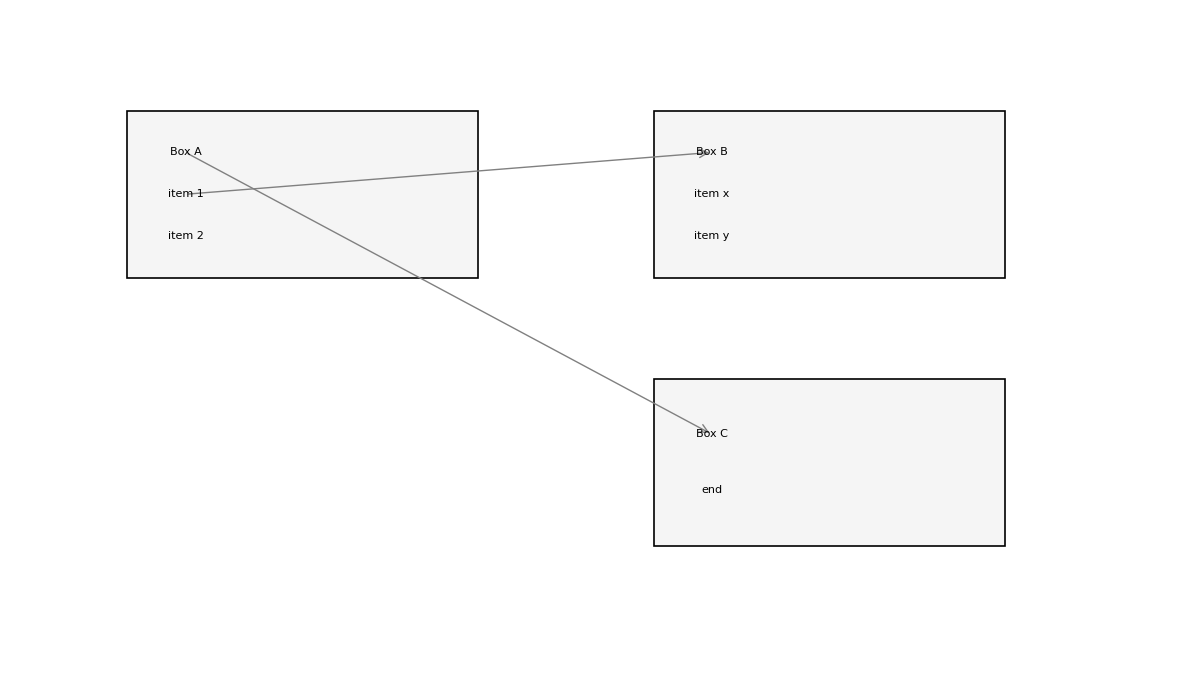

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

def draw_box(ax, xy, width, height, text, bgcolor='whitesmoke'):
    x, y = xy
    rect = Rectangle((x, y), width, height, facecolor=bgcolor, edgecolor='black', linewidth=1.2)
    ax.add_patch(rect)

    lines = text.split("\n")
    line_height = height / (len(lines) + 1)

    # store coordinates of each text line
    item_positions = []

    for i, line in enumerate(lines, start=1):
        text_x = x + 0.05         # indent inside box
        text_y = y + height - i*line_height

        ax.text(text_x, text_y, line, fontsize=8, va='center', ha='center')

        # return the *middle* of the line area for arrow connection
        item_positions.append((text_x, text_y))

    return item_positions


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(start, end, arrowstyle='->',
                            mutation_scale=15, linewidth=1, color='gray')
    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(12, 7))

# Draw boxes
A_items = draw_box(ax, (0.1, 0.6), 0.3, 0.25, "Box A\nitem 1\nitem 2")
B_items = draw_box(ax, (0.55, 0.6), 0.3, 0.25, "Box B\nitem x\nitem y")
C_items = draw_box(ax, (0.55, 0.2), 0.3, 0.25, "Box C\nend")

# Draw item-to-item arrows
draw_arrow(ax, A_items[1], B_items[0])   # item2 → item x
draw_arrow(ax, A_items[0], C_items[0])   # item1 → end

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()
